# GPU Runtime Benchmarks: Radix Tree vs KD-Tree

This notebook provides two benchmark tracks:

1. **Single-GPU runtime vs particle count** for:
   - Radix tree: build + FMM-style dual-tree traversal
   - KD-tree: build + kNN query
2. **Multi-GPU scaling** on a fixed large problem size using JAX `pmap`.

Notes:
- The scaling section measures **throughput scaling** (more independent work done in parallel with more GPUs).
- For fair timing, all measurements are synchronized with `block_until_ready()`.


## GPU Selection (Optional)

Run this cell **before any JAX import** to select GPUs automatically via `autocvd` or manually via `CUDA_VISIBLE_DEVICES`.


In [1]:
import os

# --- Option A: automatic GPU selection with autocvd ---
USE_AUTOCVD = False
AUTOCVD_NUM_GPUS = 1
AUTOCVD_LEAST_USED = True
AUTOCVD_EXCLUDE = []

# --- Option B: manual selection (set to string like '0' or '0,1') ---
MANUAL_CUDA_VISIBLE_DEVICES = "0" #None #"1,2,3,4,5,6,7,8,9"#None

if MANUAL_CUDA_VISIBLE_DEVICES is not None:
    os.environ['CUDA_VISIBLE_DEVICES'] = MANUAL_CUDA_VISIBLE_DEVICES
    print('Set CUDA_VISIBLE_DEVICES =', os.environ['CUDA_VISIBLE_DEVICES'])
elif USE_AUTOCVD:
    try:
        from autocvd import autocvd

        autocvd(
            num_gpus=AUTOCVD_NUM_GPUS,
            least_used=AUTOCVD_LEAST_USED,
            exclude=AUTOCVD_EXCLUDE,
        )
        print('autocvd selected CUDA_VISIBLE_DEVICES =', os.environ.get('CUDA_VISIBLE_DEVICES'))
    except ImportError:
        print('autocvd is not installed. Install it or set MANUAL_CUDA_VISIBLE_DEVICES.')
else:
    print('Using existing CUDA visibility:', os.environ.get('CUDA_VISIBLE_DEVICES', '<all visible>'))


Set CUDA_VISIBLE_DEVICES = 0


In [2]:
import json
import os
import subprocess
import sys
import time
from dataclasses import dataclass

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from yggdrax import (
    DualTreeTraversalConfig,
    build_interactions_and_neighbors,
    build_kdtree,
    build_tree,
    compute_tree_geometry,
    query_neighbors,
)

print("JAX backend:", jax.default_backend())
print("Visible devices:", jax.devices())


JAX backend: gpu
Visible devices: [CudaDevice(id=0)]


In [3]:
@dataclass
class SweepConfig:
    n_values: tuple[int, ...] = (4096, 8192, 16384, 32768, 65536, 131072, 262144, 524288, 1048576)
    kd_leaf_size: int = 64
    kd_k: int = 8
    kd_max_queries: int = 32768
    kd_block_size: int = 4096
    radix_leaf_size: int = 64
    theta: float = 0.6
    mac_type: str = "dehnen"
    repeats: int = 3
    traversal_process_block: int = 256

    # Traversal benchmarking mode:
    # - "calibrate": find a default fixed traversal config on calib_n
    # - "production": use production_traversal_cfg directly
    run_mode: str = "production"
    calib_n: int = 131072

    # If True, perform per-N preflight cap resolution.
    enforce_valid_radix_points: bool = True

    # Run per-N preflight even in production mode.
    # Keep False by default to avoid callback-noise during normal benchmark runs.
    preflight_in_production: bool = False

    # Safety bound for directed cap probing.
    max_probe_attempts: int = 18

    # Fixed production config (max_neighbors_per_leaf, max_interactions_per_node, max_pair_queue)
    production_traversal_cfg: tuple[int, int, int] = (512, 512, 131072)

    # Use a deterministic per-N production schedule to avoid capacity overflows.
    use_fixed_cap_schedule: bool = True
    traversal_cap_schedule: tuple[tuple[int, tuple[int, int, int]], ...] = (
        (8192, (256, 256, 65536)),
        (16384, (512, 512, 65536)),
        (32768, (1024, 512, 131072)),
        (65536, (2048, 1024, 131072)),
        (131072, (4096, 1024, 262144)),
    )

    # Per-node/per-leaf capacity candidates (small -> large)
    per_node_candidates: tuple[tuple[int, int], ...] = (
        (128, 128),
        (256, 256),
        (512, 512),
        (1024, 1024),
        (2048, 2048),
        (4096, 4096),
    )

    # Queue candidates (small -> large). This is the usual bottleneck.
    queue_candidates: tuple[int, ...] = (
        8192,
        16384,
        32768,
        65536,
        131072,
        262144,
        524288,
        1048576,
    )


cfg = SweepConfig()
cfg


SweepConfig(n_values=(4096, 8192, 16384, 32768, 65536, 131072, 262144, 524288, 1048576), kd_leaf_size=64, kd_k=8, kd_max_queries=32768, kd_block_size=4096, radix_leaf_size=64, theta=0.6, mac_type='dehnen', repeats=3, traversal_process_block=256, run_mode='production', calib_n=131072, enforce_valid_radix_points=True, preflight_in_production=False, max_probe_attempts=18, production_traversal_cfg=(512, 512, 131072), use_fixed_cap_schedule=True, traversal_cap_schedule=((8192, (256, 256, 65536)), (16384, (512, 512, 65536)), (32768, (1024, 512, 131072)), (65536, (2048, 1024, 131072)), (131072, (4096, 1024, 262144))), per_node_candidates=((128, 128), (256, 256), (512, 512), (1024, 1024), (2048, 2048), (4096, 4096)), queue_candidates=(8192, 16384, 32768, 65536, 131072, 262144, 524288, 1048576))

## Locked Recommended Setup

Based on the latest knob sweep on A100, the runtime benchmark uses:

- `radix_leaf_size = 64`
- `traversal_process_block = 256`

Traversal cap tuple order:

- `(max_neighbors_per_leaf, max_interactions_per_node, max_pair_queue)`

Current per-`N` cap schedule:

- `N <= 8,192`: `(256, 256, 65,536)`
- `N <= 16,384`: `(512, 512, 65,536)`
- `N <= 32,768`: `(1024, 512, 131,072)`
- `N <= 65,536`: `(2048, 1024, 131,072)`
- `N <= 131,072`: `(4096, 1024, 262,144)`

If hardware/backend changes, rerun the knob sweep cell and update this section.



In [4]:
def _sync_tree(tree):
    jax.tree_util.tree_map(
        lambda x: x.block_until_ready() if hasattr(x, "block_until_ready") else x,
        tree,
    )


def timed_call(fn, *args, repeats=3, warmup=1):
    for _ in range(warmup):
        out = fn(*args)
        _sync_tree(out)

    times_ms = []
    out = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        out = fn(*args)
        _sync_tree(out)
        times_ms.append((time.perf_counter() - t0) * 1e3)

    return float(min(times_ms)), float(np.mean(times_ms)), out


def _is_probable_oom(err: Exception) -> bool:
    msg = str(err).lower()
    return (
        "resource_exhausted" in msg
        or "out of memory" in msg
        or "cuda_error_out_of_memory" in msg
    )


def _make_traversal_cfg(cap: tuple[int, int, int], process_block: int) -> DualTreeTraversalConfig:
    max_neighbors, max_interactions, max_pair_queue = cap
    return DualTreeTraversalConfig(
        max_pair_queue=max_pair_queue,
        process_block=int(process_block),
        max_interactions_per_node=max_interactions,
        max_neighbors_per_leaf=max_neighbors,
    )


def _cap_for_n(n: int, cfg: SweepConfig, default_cap: tuple[int, int, int]) -> tuple[int, int, int]:
    if not cfg.use_fixed_cap_schedule:
        return default_cap
    for n_max, cap in cfg.traversal_cap_schedule:
        if n <= n_max:
            return cap
    return cfg.traversal_cap_schedule[-1][1]


def _run_radix_traversal_once(tree, geom, *, theta, mac_type, cap, process_block, return_result=False):
    traversal_cfg = _make_traversal_cfg(cap, process_block)
    return build_interactions_and_neighbors(
        tree,
        geom,
        theta=theta,
        mac_type=mac_type,
        traversal_config=traversal_cfg,
        return_result=return_result,
    )


def _next_geq(values, current):
    for v in values:
        if v >= current:
            return v
    return values[-1]


def _next_strict(values, current):
    for v in values:
        if v > current:
            return v
    return None


def _probe_cap_for_tree(tree, geom, cfg: SweepConfig, verbose: bool = False):
    """Directed, bounded cap search (avoids Cartesian explosion)."""

    n_vals = sorted({n for n, _ in cfg.per_node_candidates})
    i_vals = sorted({i for _, i in cfg.per_node_candidates})
    q_vals = sorted(cfg.queue_candidates)

    n_cap = _next_geq(n_vals, cfg.production_traversal_cfg[0])
    i_cap = _next_geq(i_vals, cfg.production_traversal_cfg[1])
    q_cap = _next_geq(q_vals, cfg.production_traversal_cfg[2])

    last_err = None
    seen = set()

    for attempt in range(cfg.max_probe_attempts):
        cap = (n_cap, i_cap, q_cap)
        if cap in seen:
            break
        seen.add(cap)

        try:
            fn = jax.jit(
                lambda t, g: _run_radix_traversal_once(
                    t,
                    g,
                    theta=cfg.theta,
                    mac_type=cfg.mac_type,
                    cap=cap,
                    process_block=cfg.traversal_process_block,
                    return_result=True,
                )
            )
            _, _, out = timed_call(fn, tree, geom, repeats=1, warmup=1)
            interactions, neighbors, result = out

            qov = bool(result.queue_overflow)
            fov = bool(result.far_overflow)
            nov = bool(result.near_overflow)

            if verbose:
                far_peak = int(jnp.max(interactions.counts))
                near_peak = int(jnp.max(neighbors.counts))
                print(
                    f"    try#{attempt+1} cap={cap} -> overflow(q/f/n)={qov}/{fov}/{nov}, "
                    f"peak_far={far_peak}, peak_near={near_peak}"
                )

            if not (qov or fov or nov):
                return cap, None

            if fov:
                nxt = _next_strict(i_vals, i_cap)
                if nxt is None:
                    return None, f"Interaction capacity overflow persists at max tested cap={cap}."
                i_cap = nxt
                continue
            if nov:
                nxt = _next_strict(n_vals, n_cap)
                if nxt is None:
                    return None, f"Neighbor capacity overflow persists at max tested cap={cap}."
                n_cap = nxt
                continue
            if qov:
                nxt = _next_strict(q_vals, q_cap)
                if nxt is None:
                    return None, f"Queue overflow persists at max tested cap={cap}."
                q_cap = nxt
                continue

        except Exception as err:
            last_err = err
            msg = str(err).lower()
            if verbose:
                print(f"    try#{attempt+1} cap={cap} failed: {type(err).__name__}: {err}")

            if _is_probable_oom(err):
                return None, f"OOM during cap probe at cap={cap}: {type(err).__name__}: {err}"
            if "interaction list capacity" in msg:
                nxt = _next_strict(i_vals, i_cap)
                if nxt is None:
                    return None, f"Interaction capacity exceeded at max tested cap={cap}."
                i_cap = nxt
                continue
            if "neighbor list capacity" in msg:
                nxt = _next_strict(n_vals, n_cap)
                if nxt is None:
                    return None, f"Neighbor capacity exceeded at max tested cap={cap}."
                n_cap = nxt
                continue
            if "queue capacity" in msg or "queue overflow" in msg:
                nxt = _next_strict(q_vals, q_cap)
                if nxt is None:
                    return None, f"Queue capacity exceeded at max tested cap={cap}."
                q_cap = nxt
                continue
            return None, f"Unhandled error during cap probe at cap={cap}: {type(err).__name__}: {err}"

    if last_err is None:
        return None, "Probe exhausted max attempts without resolving overflows."
    return None, f"Probe exhausted max attempts. Last error: {type(last_err).__name__}: {last_err}"


def calibrate_traversal_config(cfg: SweepConfig, seed: int = 0) -> tuple[int, int, int]:
    n = int(cfg.calib_n)
    key = jax.random.PRNGKey(seed)
    key_p, key_m = jax.random.split(key)

    points = jax.random.uniform(
        key_p, (n, 3), minval=-1.0, maxval=1.0, dtype=jnp.float32
    )
    masses = jax.random.uniform(
        key_m, (n,), minval=0.5, maxval=1.5, dtype=jnp.float32
    )

    build_fn = jax.jit(
        lambda p, m: build_tree(
            p,
            m,
            leaf_size=cfg.radix_leaf_size,
            return_reordered=True,
        )
    )
    _, _, payload = timed_call(build_fn, points, masses, repeats=1, warmup=1)
    tree, pos_sorted, _, _ = payload

    geom_fn = jax.jit(lambda t, p: compute_tree_geometry(t, p))
    _, _, geom = timed_call(geom_fn, tree, pos_sorted, repeats=1, warmup=1)

    print(f"Calibrating traversal config at N={n} ...")
    cap, err = _probe_cap_for_tree(tree, geom, cfg, verbose=True)
    if cap is None:
        raise RuntimeError(f"Calibration failed: {err}")

    print(f"  selected calibrated config: {cap}")
    return cap


In [5]:
def benchmark_single_gpu(
    n: int,
    cfg: SweepConfig,
    traversal_cap: tuple[int, int, int],
    seed: int = 0,
    points: jnp.ndarray | None = None,
    masses: jnp.ndarray | None = None,
    queries: jnp.ndarray | None = None,
) -> dict:
    if points is None or masses is None or queries is None:
        key = jax.random.PRNGKey(seed)
        key_p, key_m, key_q = jax.random.split(key, 3)

        points = jax.random.uniform(
            key_p, (n, 3), minval=-1.0, maxval=1.0, dtype=jnp.float32
        )
        masses = jax.random.uniform(
            key_m, (n,), minval=0.5, maxval=1.5, dtype=jnp.float32
        )

        q = min(n, cfg.kd_max_queries)
        queries = jax.random.uniform(
            key_q, (q, 3), minval=-1.0, maxval=1.0, dtype=jnp.float32
        )
    else:
        q = int(queries.shape[0])

    # ----- KD-tree: build + query -----
    kd_build_fn = jax.jit(lambda p: build_kdtree(p, leaf_size=cfg.kd_leaf_size))
    kd_build_min, kd_build_avg, kd_tree = timed_call(
        kd_build_fn, points, repeats=cfg.repeats
    )

    kd_query_fn = jax.jit(
        lambda t, qq: query_neighbors(
            t,
            qq,
            k=cfg.kd_k,
            backend="auto",
            point_block_size=cfg.kd_block_size,
            return_squared=True,
        )
    )
    kd_query_min, kd_query_avg, _ = timed_call(
        kd_query_fn, kd_tree, queries, repeats=cfg.repeats
    )

    # ----- Radix: build + geometry + traversal (fixed config, no retries) -----
    radix_build_fn = jax.jit(
        lambda p, m: build_tree(
            p,
            m,
            leaf_size=cfg.radix_leaf_size,
            return_reordered=True,
        )
    )
    radix_build_min, radix_build_avg, radix_payload = timed_call(
        radix_build_fn, points, masses, repeats=cfg.repeats
    )
    radix_tree, pos_sorted, _, _ = radix_payload

    geom_fn = jax.jit(lambda t, p: compute_tree_geometry(t, p))
    geom_min, geom_avg, geom = timed_call(
        geom_fn, radix_tree, pos_sorted, repeats=cfg.repeats
    )

    trav_min = float("nan")
    trav_avg = float("nan")
    trav_error = None

    trav_fn = jax.jit(
        lambda t, g: _run_radix_traversal_once(
            t,
            g,
            theta=cfg.theta,
            mac_type=cfg.mac_type,
            cap=traversal_cap,
            process_block=cfg.traversal_process_block,
            return_result=False,
        )
    )
    try:
        trav_min, trav_avg, _ = timed_call(
            trav_fn, radix_tree, geom, repeats=cfg.repeats
        )
    except Exception as err:
        trav_error = f"{type(err).__name__}: {err}"

    return {
        "n": n,
        "kd_build_ms_min": kd_build_min,
        "kd_build_ms_avg": kd_build_avg,
        "kd_query_ms_min": kd_query_min,
        "kd_query_ms_avg": kd_query_avg,
        "radix_build_ms_min": radix_build_min,
        "radix_build_ms_avg": radix_build_avg,
        "radix_geom_ms_min": geom_min,
        "radix_geom_ms_avg": geom_avg,
        "radix_traversal_ms_min": trav_min,
        "radix_traversal_ms_avg": trav_avg,
        "radix_traversal_error": trav_error,
        "traversal_cap_used": traversal_cap,
        "kd_queries": q,
    }


In [6]:
if "cfg" not in globals():
    if "SweepConfig" in globals():
        cfg = SweepConfig()
        print("cfg was not defined; created default SweepConfig().")
    else:
        raise RuntimeError("Run the configuration cell first (the one defining SweepConfig and cfg).")

if cfg.run_mode not in {"calibrate", "production"}:
    raise ValueError(f"cfg.run_mode must be 'calibrate' or 'production', got {cfg.run_mode}")

if cfg.run_mode == "calibrate":
    calib_candidates = []
    for n_try in (cfg.calib_n, cfg.calib_n // 2, cfg.calib_n // 4):
        n_try = int(max(4096, n_try))
        if n_try not in calib_candidates:
            calib_candidates.append(n_try)

    traversal_cap_default = None
    calibration_error = None
    original_calib_n = cfg.calib_n

    for n_try in calib_candidates:
        cfg.calib_n = n_try
        try:
            print(f"Trying calibration with calib_n={n_try} ...")
            traversal_cap_default = calibrate_traversal_config(cfg, seed=0)
            calibration_error = None
            break
        except Exception as err:
            calibration_error = err
            print(f"  calibration failed at calib_n={n_try}: {type(err).__name__}: {err}")
            if not _is_probable_oom(err):
                break

    cfg.calib_n = original_calib_n

    if traversal_cap_default is None:
        print(
            "WARNING: calibration did not succeed. Falling back to cfg.production_traversal_cfg."
        )
        print(f"  last calibration error: {type(calibration_error).__name__}: {calibration_error}")
        traversal_cap_default = cfg.production_traversal_cfg
else:
    traversal_cap_default = cfg.production_traversal_cfg

print("Default fixed traversal config:", traversal_cap_default)

single_gpu_results = []
for i, n in enumerate(cfg.n_values):
    print(f"Running single-GPU sweep for N={n} ...")

    key = jax.random.PRNGKey(i)
    key_p, key_m, key_q = jax.random.split(key, 3)
    points = jax.random.uniform(key_p, (n, 3), minval=-1.0, maxval=1.0, dtype=jnp.float32)
    masses = jax.random.uniform(key_m, (n,), minval=0.5, maxval=1.5, dtype=jnp.float32)
    q = min(n, cfg.kd_max_queries)
    queries = jax.random.uniform(key_q, (q, 3), minval=-1.0, maxval=1.0, dtype=jnp.float32)

    traversal_cap_for_n = _cap_for_n(n, cfg, traversal_cap_default)
    cap_resolution_error = None

    should_preflight = cfg.enforce_valid_radix_points and (
        cfg.run_mode == "calibrate" or cfg.preflight_in_production
    )

    if should_preflight:
        build_probe = jax.jit(lambda p, m: build_tree(p, m, leaf_size=cfg.radix_leaf_size, return_reordered=True))
        _, _, payload = timed_call(build_probe, points, masses, repeats=1, warmup=1)
        tree_probe, pos_probe, _, _ = payload
        geom_probe_fn = jax.jit(lambda t, p: compute_tree_geometry(t, p))
        _, _, geom_probe = timed_call(geom_probe_fn, tree_probe, pos_probe, repeats=1, warmup=1)

        cap_found, cap_err = _probe_cap_for_tree(tree_probe, geom_probe, cfg, verbose=False)
        if cap_found is not None:
            traversal_cap_for_n = cap_found
        else:
            cap_resolution_error = cap_err
            print(f"  cap preflight failed for N={n}: {cap_err}")

    stats = benchmark_single_gpu(
        n=n,
        cfg=cfg,
        traversal_cap=traversal_cap_for_n,
        seed=i,
        points=points,
        masses=masses,
        queries=queries,
    )

    stats["traversal_cap_preflight_error"] = cap_resolution_error
    if stats["radix_traversal_error"] is not None:
        print("  radix traversal failed:", stats["radix_traversal_error"])
    single_gpu_results.append(stats)

single_gpu_results


Default fixed traversal config: (512, 512, 131072)
Running single-GPU sweep for N=4096 ...
Running single-GPU sweep for N=8192 ...
Running single-GPU sweep for N=16384 ...
Running single-GPU sweep for N=32768 ...
Running single-GPU sweep for N=65536 ...
Running single-GPU sweep for N=131072 ...
Running single-GPU sweep for N=262144 ...
Running single-GPU sweep for N=524288 ...
Running single-GPU sweep for N=1048576 ...


[{'n': 4096,
  'kd_build_ms_min': 3.0443640425801277,
  'kd_build_ms_avg': 3.1238713612159095,
  'kd_query_ms_min': 1.8954193219542503,
  'kd_query_ms_avg': 1.910143221418063,
  'radix_build_ms_min': 1.0701054707169533,
  'radix_build_ms_avg': 1.1088053385416667,
  'radix_geom_ms_min': 0.646212138235569,
  'radix_geom_ms_avg': 0.6722727169593176,
  'radix_traversal_ms_min': 8.098469115793705,
  'radix_traversal_ms_avg': 8.353390730917454,
  'radix_traversal_error': None,
  'traversal_cap_used': (256, 256, 65536),
  'kd_queries': 4096,
  'traversal_cap_preflight_error': None},
 {'n': 8192,
  'kd_build_ms_min': 4.149741493165493,
  'kd_build_ms_avg': 4.234280747671922,
  'kd_query_ms_min': 7.603277452290058,
  'kd_query_ms_avg': 7.622723778088887,
  'radix_build_ms_min': 0.9847553446888924,
  'radix_build_ms_avg': 1.0513421148061752,
  'radix_geom_ms_min': 0.8913744240999222,
  'radix_geom_ms_avg': 0.9329042707880338,
  'radix_traversal_ms_min': 9.141265414655209,
  'radix_traversal_ms_a

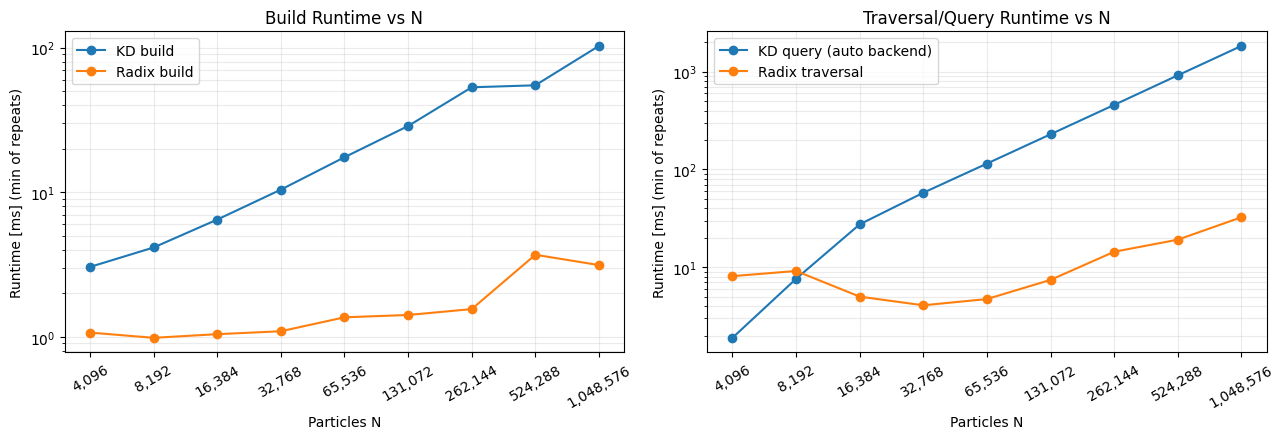

In [7]:
n_vals = np.array([r["n"] for r in single_gpu_results], dtype=np.int64)

kd_build = np.array([r["kd_build_ms_min"] for r in single_gpu_results], dtype=np.float64)
kd_query = np.array([r["kd_query_ms_min"] for r in single_gpu_results], dtype=np.float64)

radix_build = np.array([r["radix_build_ms_min"] for r in single_gpu_results], dtype=np.float64)
radix_trav = np.array([r["radix_traversal_ms_min"] for r in single_gpu_results], dtype=np.float64)
radix_ok = np.isfinite(radix_trav)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(n_vals, kd_build, marker="o", label="KD build")
axes[0].plot(n_vals, radix_build, marker="o", label="Radix build")
axes[0].set_xscale("log", base=2)
axes[0].set_yscale("log")
axes[0].set_xticks(n_vals)
axes[0].set_xticklabels([f"{int(x):,}" for x in n_vals], rotation=30)
axes[0].set_xlabel("Particles N")
axes[0].set_ylabel("Runtime [ms] (min of repeats)")
axes[0].set_title("Build Runtime vs N")
axes[0].grid(True, which="both", alpha=0.25)
axes[0].legend()

axes[1].plot(n_vals, kd_query, marker="o", label="KD query (auto backend)")
if np.any(radix_ok):
    axes[1].plot(n_vals[radix_ok], radix_trav[radix_ok], marker="o", label="Radix traversal")
else:
    print("No valid radix traversal points were collected in single_gpu_results.")

axes[1].set_xscale("log", base=2)
axes[1].set_yscale("log")
axes[1].set_xticks(n_vals)
axes[1].set_xticklabels([f"{int(x):,}" for x in n_vals], rotation=30)
axes[1].set_xlabel("Particles N")
axes[1].set_ylabel("Runtime [ms] (min of repeats)")
axes[1].set_title("Traversal/Query Runtime vs N")
axes[1].grid(True, which="both", alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

if np.any(~radix_ok):
    print("Radix traversal missing points:")
    for r in single_gpu_results:
        if not np.isfinite(r["radix_traversal_ms_min"]):
            print(f"  N={r['n']:,}")
            print(f"    preflight cap error: {r.get('traversal_cap_preflight_error')}")
            print(f"    traversal error:     {r['radix_traversal_error']}")


## Multi-GPU Scaling (Throughput)

This section runs subprocess benchmarks for different GPU counts by setting `CUDA_VISIBLE_DEVICES` per run.

Each device processes one independent large workload via `pmap`; scaling is reported as throughput and speedup relative to 1 GPU.


In [ ]:
_SCALING_SCRIPT = r'''
import json
import sys
import time

import jax
import jax.numpy as jnp

from yggdrax import (
    DualTreeTraversalConfig,
    build_interactions_and_neighbors,
    build_kdtree,
    build_tree,
    compute_tree_geometry,
    query_neighbors,
)

n = int(sys.argv[1])
repeats = int(sys.argv[2])
kd_leaf = int(sys.argv[3])
k = int(sys.argv[4])
kd_block = int(sys.argv[5])
radix_neighbors = int(sys.argv[6])
radix_interactions = int(sys.argv[7])
radix_queue = int(sys.argv[8])
radix_leaf = int(sys.argv[9])
radix_process_block = int(sys.argv[10])

num_devices = len(jax.devices())
if num_devices < 1:
    raise RuntimeError("No visible JAX devices.")

key = jax.random.PRNGKey(0)
keys = jax.random.split(key, 2)
points = jax.random.uniform(keys[0], (num_devices, n, 3), minval=-1.0, maxval=1.0, dtype=jnp.float32)
masses = jax.random.uniform(keys[1], (num_devices, n), minval=0.5, maxval=1.5, dtype=jnp.float32)

q = min(n, 32768)

@jax.pmap
def kd_step(p):
    tree = build_kdtree(p, leaf_size=kd_leaf)
    idx, d2 = query_neighbors(
        tree,
        p[:q],
        k=k,
        backend="auto",
        point_block_size=kd_block,
        return_squared=True,
    )
    return jnp.sum(d2)


def _make_radix_step(cap):
    max_neighbors, max_interactions, max_pair_queue = cap

    @jax.pmap
    def radix_step(p, m):
        tree, pos_sorted, _mass_sorted, _inv = build_tree(
            p,
            m,
            leaf_size=radix_leaf,
            return_reordered=True,
        )
        geom = compute_tree_geometry(tree, pos_sorted)
        traversal_cfg = DualTreeTraversalConfig(
            max_pair_queue=max_pair_queue,
            process_block=radix_process_block,
            max_interactions_per_node=max_interactions,
            max_neighbors_per_leaf=max_neighbors,
        )
        interactions, neighbors = build_interactions_and_neighbors(
            tree,
            geom,
            theta=0.6,
            mac_type="dehnen",
            traversal_config=traversal_cfg,
        )
        return jnp.sum(interactions.counts) + jnp.sum(neighbors.counts)

    return radix_step


def _is_retryable_capacity_error(exc):
    msg = str(exc).lower()
    return (
        "capacity exceeded" in msg
        or "interaction list capacity" in msg
        or "neighbor list capacity" in msg
        or "queue capacity" in msg
        or "overflow" in msg
    )


def _is_oom(exc):
    msg = str(exc).lower()
    return (
        "resource_exhausted" in msg
        or "out of memory" in msg
        or "cuda_error_out_of_memory" in msg
    )


def measure(fn, *args):
    out = fn(*args)
    jax.tree_util.tree_map(lambda x: x.block_until_ready(), out)
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        out = fn(*args)
        jax.tree_util.tree_map(lambda x: x.block_until_ready(), out)
        times.append((time.perf_counter() - t0) * 1e3)
    return float(min(times))


kd_ms = measure(kd_step, points)

base_cap = (radix_neighbors, radix_interactions, radix_queue)
cap_trials = [
    base_cap,
    (base_cap[0] * 2, base_cap[1] * 2, base_cap[2] * 2),
    (base_cap[0] * 4, base_cap[1] * 4, base_cap[2] * 4),
]

radix_error = None
radix_ms = None
radix_cap_used = None

for cap in cap_trials:
    try:
        radix_step = _make_radix_step(cap)
        radix_ms = measure(radix_step, points, masses)
        radix_cap_used = cap
        break
    except Exception as exc:
        radix_error = f"{type(exc).__name__}: {exc}"
        if _is_oom(exc):
            break
        if _is_retryable_capacity_error(exc):
            continue
        break

result = {
    "num_devices": num_devices,
    "n_per_device": n,
    "q_per_device": q,
    "kd_ms_min": kd_ms,
    "kd_total_queries": int(num_devices * q),
    "kd_queries_per_sec": float((num_devices * q) / (kd_ms / 1e3)),
    "radix_ms_min": radix_ms,
    "radix_cap_used": radix_cap_used,
    "radix_total_particles": int(num_devices * n),
    "radix_particles_per_sec": None if radix_ms is None else float((num_devices * n) / (radix_ms / 1e3)),
    "radix_error": radix_error,
}
print(json.dumps(result))
'''


def run_scaling_point(
    num_gpus: int,
    n_per_device: int,
    repeats: int,
    kd_leaf: int,
    k: int,
    kd_block: int,
    radix_cap: tuple[int, int, int],
    radix_leaf: int,
    radix_process_block: int,
):
    env = os.environ.copy()
    env["CUDA_VISIBLE_DEVICES"] = ",".join(str(i) for i in range(num_gpus))

    proc = subprocess.run(
        [
            sys.executable,
            "-c",
            _SCALING_SCRIPT,
            str(n_per_device),
            str(repeats),
            str(kd_leaf),
            str(k),
            str(kd_block),
            str(radix_cap[0]),
            str(radix_cap[1]),
            str(radix_cap[2]),
            str(radix_leaf),
            str(radix_process_block),
        ],
        env=env,
        check=True,
        capture_output=True,
        text=True,
    )
    return json.loads(proc.stdout.strip())


In [ ]:
# Adjust based on available GPUs and memory.
num_gpus_to_test = [1, 2, 4, 8]
n_per_device = 16384
repeats_scaling = 3
radix_cap_for_scaling = traversal_cap_default if "traversal_cap_default" in globals() else cfg.production_traversal_cfg

scaling_results = []
for g in num_gpus_to_test:
    print(f"Running scaling benchmark with {g} GPU(s) ...")
    try:
        scaling_results.append(
            run_scaling_point(
                num_gpus=g,
                n_per_device=n_per_device,
                repeats=repeats_scaling,
                kd_leaf=cfg.kd_leaf_size,
                k=cfg.kd_k,
                kd_block=cfg.kd_block_size,
                radix_cap=radix_cap_for_scaling,
                radix_leaf=cfg.radix_leaf_size,
                radix_process_block=cfg.traversal_process_block,
            )
        )
    except subprocess.CalledProcessError as err:
        print(f"  failed for {g} GPUs")
        print(err.stderr[-1000:])

scaling_results


Running scaling benchmark with 1 GPU(s) ...
Running scaling benchmark with 2 GPU(s) ...
Running scaling benchmark with 4 GPU(s) ...
Running scaling benchmark with 8 GPU(s) ...


[{'num_devices': 1,
  'n_per_device': 16384,
  'q_per_device': 16384,
  'kd_ms_min': 44.95557816699147,
  'kd_total_queries': 16384,
  'kd_queries_per_sec': 364448.65505099687,
  'radix_ms_min': 109.0460391715169,
  'radix_cap_used': [1024, 1024, 262144],
  'radix_total_particles': 16384,
  'radix_particles_per_sec': 150248.46500137294,
  'radix_error': 'JaxRuntimeError: INTERNAL: CpuCallback error calling callback: Traceback (most recent call last):\n  File "<string>", line 130, in <module>\n  File "<string>", line 103, in measure\n  File "/export/home/tbuck/micromamba/envs/odisseo/lib/python3.13/site-packages/jax/_src/pmap.py", line 101, in wrapped\n  File "/export/home/tbuck/micromamba/envs/odisseo/lib/python3.13/site-packages/jax/_src/traceback_util.py", line 198, in reraise_with_filtered_traceback\n  File "/export/home/tbuck/micromamba/envs/odisseo/lib/python3.13/site-packages/jax/_src/pjit.py", line 256, in cache_miss\n  File "/export/home/tbuck/micromamba/envs/odisseo/lib/python

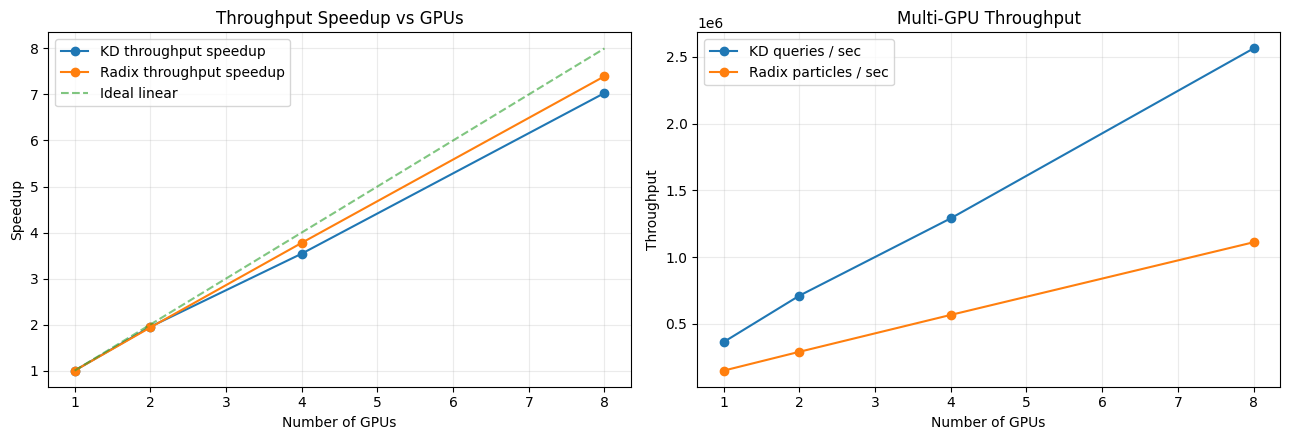

radix error for 1 GPUs: JaxRuntimeError: INTERNAL: CpuCallback error calling callback: Traceback (most recent call last):
  File "<string>", line 130, in <module>
  File "<string>", line 103, in measure
  File "/export/home/tbuck/micromamba/envs/odisseo/lib/python3.13/site-packages/jax/_src/pmap.py", line 101, in wrapped
  File "/export/home/tbuck/micromamba/envs/odisseo/lib/python3.13/site-packages/jax/_src/traceback_util.py", line 198, in reraise_with_filtered_traceback
  File "/export/home/tbuck/micromamba/envs/odisseo/lib/python3.13/site-packages/jax/_src/pjit.py", line 256, in cache_miss
  File "/export/home/tbuck/micromamba/envs/odisseo/lib/python3.13/site-packages/jax/_src/pjit.py", line 141, in _run_python_pjit
  File "/export/home/tbuck/micromamba/envs/odisseo/lib/python3.13/site-packages/jax/_src/pjit.py", line 1239, in _pjit_call_impl_python
  File "/export/home/tbuck/micromamba/envs/odisseo/lib/python3.13/site-packages/jax/_src/profiler.py", line 384, in wrapper
  File "/ex

In [ ]:
if scaling_results:
    gpus = np.array([r["num_devices"] for r in scaling_results], dtype=np.int64)

    kd_tp = np.array([r["kd_queries_per_sec"] for r in scaling_results], dtype=np.float64)
    kd_speedup = kd_tp / kd_tp[0]

    radix_tp = np.array([
        np.nan if r["radix_particles_per_sec"] is None else r["radix_particles_per_sec"]
        for r in scaling_results
    ], dtype=np.float64)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(gpus, kd_speedup, marker="o", label="KD throughput speedup")

    radix_ok = np.isfinite(radix_tp)
    if np.any(radix_ok):
        finite_idx = np.where(radix_ok)[0]
        baseline_idx = finite_idx[0]
        radix_speedup = radix_tp / radix_tp[baseline_idx]
        axes[0].plot(gpus[radix_ok], radix_speedup[radix_ok], marker="o", label="Radix throughput speedup")
    else:
        print("No valid radix multi-GPU throughput points were collected.")

    axes[0].plot(gpus, gpus / gpus[0], linestyle="--", alpha=0.6, label="Ideal linear")
    axes[0].set_xlabel("Number of GPUs")
    axes[0].set_ylabel("Speedup")
    axes[0].set_title("Throughput Speedup vs GPUs")
    axes[0].grid(True, alpha=0.25)
    axes[0].legend()

    axes[1].plot(gpus, kd_tp, marker="o", label="KD queries / sec")
    if np.any(radix_ok):
        axes[1].plot(gpus[radix_ok], radix_tp[radix_ok], marker="o", label="Radix particles / sec")
    axes[1].set_xlabel("Number of GPUs")
    axes[1].set_ylabel("Throughput")
    axes[1].set_title("Multi-GPU Throughput")
    axes[1].grid(True, alpha=0.25)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    for r in scaling_results:
        if r.get("radix_error"):
            print(f"radix error for {r['num_devices']} GPUs: {r['radix_error']}")
        else:
            print(f"radix cap used for {r['num_devices']} GPUs: {r.get('radix_cap_used')}")
else:
    print("No scaling results collected.")


## Multi-GPU Strong Scaling (Fixed Total Work)

This section keeps total work fixed across GPU counts (strong scaling).

- `N_total` is split across GPUs: `n_per_device = N_total / g`.
- Ideal runtime curve scales as `1/g`.
- Parallel efficiency is `T(1) / (g * T(g))` (ideal = 1).


In [ ]:
# Strong scaling configuration (fixed total work)
num_gpus_strong = [1, 2, 4, 8]
N_total = 131072
repeats_strong = 3
radix_cap_for_strong = traversal_cap_default if "traversal_cap_default" in globals() else cfg.production_traversal_cfg

strong_results = []
for g in num_gpus_strong:
    if N_total % g != 0:
        print(f"Skipping g={g}: N_total={N_total} not divisible by {g}")
        continue

    n_per_device = N_total // g
    print(f"Running strong scaling with {g} GPU(s), n_per_device={n_per_device} ...")
    try:
        strong_results.append(
            run_scaling_point(
                num_gpus=g,
                n_per_device=n_per_device,
                repeats=repeats_strong,
                kd_leaf=cfg.kd_leaf_size,
                k=cfg.kd_k,
                kd_block=cfg.kd_block_size,
                radix_cap=radix_cap_for_strong,
                radix_leaf=cfg.radix_leaf_size,
                radix_process_block=cfg.traversal_process_block,
            )
        )
    except subprocess.CalledProcessError as err:
        print(f"  failed for {g} GPUs")
        print(err.stderr[-1000:])

strong_results


Running strong scaling with 1 GPU(s), n_per_device=131072 ...
Running strong scaling with 2 GPU(s), n_per_device=65536 ...
Running strong scaling with 4 GPU(s), n_per_device=32768 ...
Running strong scaling with 8 GPU(s), n_per_device=16384 ...


[{'num_devices': 1,
  'n_per_device': 131072,
  'q_per_device': 32768,
  'kd_ms_min': 616.0794580355287,
  'kd_total_queries': 32768,
  'kd_queries_per_sec': 53187.94446496592,
  'radix_ms_min': 77.34696101397276,
  'radix_cap_used': [512, 512, 131072],
  'radix_total_particles': 131072,
  'radix_particles_per_sec': 1694597.929662961,
  'radix_error': None},
 {'num_devices': 2,
  'n_per_device': 65536,
  'q_per_device': 32768,
  'kd_ms_min': 309.1268907301128,
  'kd_total_queries': 65536,
  'kd_queries_per_sec': 212003.55570883365,
  'radix_ms_min': 65.50166802480817,
  'radix_cap_used': [512, 512, 131072],
  'radix_total_particles': 131072,
  'radix_particles_per_sec': 2001048.2778905365,
  'radix_error': None},
 {'num_devices': 4,
  'n_per_device': 32768,
  'q_per_device': 32768,
  'kd_ms_min': 154.7731631435454,
  'kd_total_queries': 131072,
  'kd_queries_per_sec': 846865.1627830104,
  'radix_ms_min': 253.13602527603507,
  'radix_cap_used': [2048, 2048, 524288],
  'radix_total_parti

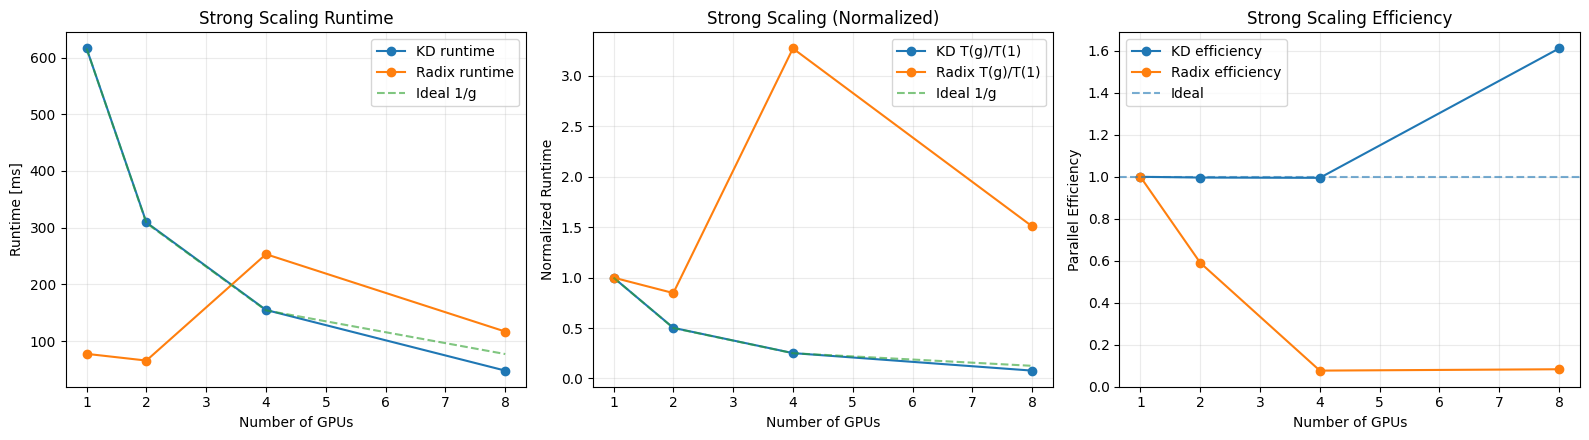

radix cap used for 1 GPUs: [512, 512, 131072]
radix cap used for 2 GPUs: [512, 512, 131072]
radix error for 4 GPUs: JaxRuntimeError: INTERNAL: CpuCallback error calling callback: Traceback (most recent call last):
  File "/export/home/tbuck/micromamba/envs/odisseo/lib/python3.13/site-packages/jax/_src/callback.py", line 817, in _wrapped_callback
  File "/export/home/tbuck/micromamba/envs/odisseo/lib/python3.13/site-packages/jax/_src/debugging.py", line 201, in _callback
  File "/export/home/tbuck/micromamba/envs/odisseo/lib/python3.13/site-packages/jax/_src/debugging.py", line 105, in debug_callback_impl
  File "/export/home/tbuck/micromamba/envs/odisseo/lib/python3.13/site-packages/jax/_src/debugging.py", line 467, in _flat_callback
  File "/export/home/tbuck/yggdrax/yggdrax/_interactions_impl.py", line 691, in _callback
RuntimeError: Neighbor list capacity exceeded; increase max_neighbors_per_leaf and rebuild.
radix error for 8 GPUs: JaxRuntimeError: INTERNAL: CpuCallback error calli

In [ ]:
if strong_results:
    gpus = np.array([r["num_devices"] for r in strong_results], dtype=np.int64)

    kd_ms = np.array([r["kd_ms_min"] for r in strong_results], dtype=np.float64)
    kd_norm = kd_ms / kd_ms[0]
    kd_eff = 1.0 / (gpus * kd_norm)

    radix_ms = np.array([
        np.nan if r["radix_ms_min"] is None else r["radix_ms_min"]
        for r in strong_results
    ], dtype=np.float64)
    radix_ok = np.isfinite(radix_ms)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    # Runtime (ms)
    axes[0].plot(gpus, kd_ms, marker="o", label="KD runtime")
    if np.any(radix_ok):
        axes[0].plot(gpus[radix_ok], radix_ms[radix_ok], marker="o", label="Radix runtime")
    axes[0].plot(gpus, kd_ms[0] / gpus, linestyle="--", alpha=0.6, label="Ideal 1/g")
    axes[0].set_xlabel("Number of GPUs")
    axes[0].set_ylabel("Runtime [ms]")
    axes[0].set_title("Strong Scaling Runtime")
    axes[0].grid(True, alpha=0.25)
    axes[0].legend()

    # Normalized runtime
    axes[1].plot(gpus, kd_norm, marker="o", label="KD T(g)/T(1)")
    if np.any(radix_ok):
        first_idx = np.where(radix_ok)[0][0]
        radix_norm = radix_ms / radix_ms[first_idx]
        axes[1].plot(gpus[radix_ok], radix_norm[radix_ok], marker="o", label="Radix T(g)/T(1)")
    axes[1].plot(gpus, 1.0 / gpus, linestyle="--", alpha=0.6, label="Ideal 1/g")
    axes[1].set_xlabel("Number of GPUs")
    axes[1].set_ylabel("Normalized Runtime")
    axes[1].set_title("Strong Scaling (Normalized)")
    axes[1].grid(True, alpha=0.25)
    axes[1].legend()

    # Parallel efficiency
    axes[2].plot(gpus, kd_eff, marker="o", label="KD efficiency")
    if np.any(radix_ok):
        first_idx = np.where(radix_ok)[0][0]
        radix_norm = radix_ms / radix_ms[first_idx]
        radix_eff = 1.0 / ((gpus / gpus[first_idx]) * radix_norm)
        axes[2].plot(gpus[radix_ok], radix_eff[radix_ok], marker="o", label="Radix efficiency")
    axes[2].axhline(1.0, linestyle="--", alpha=0.6, label="Ideal")
    axes[2].set_xlabel("Number of GPUs")
    axes[2].set_ylabel("Parallel Efficiency")
    axes[2].set_title("Strong Scaling Efficiency")
    axes[2].grid(True, alpha=0.25)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    for r in strong_results:
        if r.get("radix_error"):
            print(f"radix error for {r['num_devices']} GPUs: {r['radix_error']}")
        else:
            print(f"radix cap used for {r['num_devices']} GPUs: {r.get('radix_cap_used')}")
else:
    print("No strong-scaling results collected.")


In [6]:
# Radix knob sweep (leaf size + process_block)
# Runs a focused search at fixed N and optionally applies best settings to cfg.

sweep_n = 131072
sweep_repeats = 3
leaf_candidates = [16, 24, 32, 48, 64]
block_candidates = [256, 512, 1024]
apply_best_to_cfg = True
seed = 123

key = jax.random.PRNGKey(seed)
kp, km = jax.random.split(key)
points = jax.random.uniform(kp, (sweep_n, 3), minval=-1.0, maxval=1.0, dtype=jnp.float32)
masses = jax.random.uniform(km, (sweep_n,), minval=0.5, maxval=1.5, dtype=jnp.float32)

radix_knob_results = []

orig_leaf = cfg.radix_leaf_size
orig_block = cfg.traversal_process_block
orig_repeats = cfg.repeats

for leaf in leaf_candidates:
    for block in block_candidates:
        cfg.radix_leaf_size = int(leaf)
        cfg.traversal_process_block = int(block)
        cfg.repeats = int(sweep_repeats)

        row = {
            'leaf_size': int(leaf),
            'process_block': int(block),
            'cap_used': None,
            'build_ms_min': float('nan'),
            'geom_ms_min': float('nan'),
            'trav_ms_min': float('nan'),
            'total_ms_min': float('nan'),
            'error': None,
        }

        try:
            build_fn = jax.jit(lambda p, m: build_tree(p, m, leaf_size=cfg.radix_leaf_size, return_reordered=True))
            bmin, _bavg, payload = timed_call(build_fn, points, masses, repeats=cfg.repeats, warmup=1)
            tree, pos_sorted, _m, _inv = payload

            geom_fn = jax.jit(lambda t, p: compute_tree_geometry(t, p))
            gmin, _gavg, geom = timed_call(geom_fn, tree, pos_sorted, repeats=cfg.repeats, warmup=1)

            cap_guess = _cap_for_n(sweep_n, cfg, cfg.production_traversal_cfg)
            cap_found, cap_err = _probe_cap_for_tree(tree, geom, cfg, verbose=False)
            cap = cap_found if cap_found is not None else cap_guess
            row['cap_used'] = tuple(int(x) for x in cap)
            if cap_found is None and cap_err is not None:
                row['error'] = f'cap_probe_fallback: {cap_err}'

            trav_fn = jax.jit(lambda t, g: _run_radix_traversal_once(
                t, g, theta=cfg.theta, mac_type=cfg.mac_type, cap=cap, process_block=cfg.traversal_process_block, return_result=False
            ))
            tmin, _tavg, _ = timed_call(trav_fn, tree, geom, repeats=cfg.repeats, warmup=1)

            row['build_ms_min'] = float(bmin)
            row['geom_ms_min'] = float(gmin)
            row['trav_ms_min'] = float(tmin)
            row['total_ms_min'] = float(bmin + gmin + tmin)

        except Exception as err:
            row['error'] = f"{type(err).__name__}: {err}"

        radix_knob_results.append(row)
        print(f"leaf={leaf:>2}, block={block:>4} -> trav={row['trav_ms_min']:.3f} ms, total={row['total_ms_min']:.3f} ms, cap={row['cap_used']}, err={row['error']}")

# restore cfg defaults unless we explicitly apply best below
cfg.radix_leaf_size = orig_leaf
cfg.traversal_process_block = orig_block
cfg.repeats = orig_repeats

valid = [r for r in radix_knob_results if np.isfinite(r['trav_ms_min'])]
if valid:
    best_trav = min(valid, key=lambda r: r['trav_ms_min'])
    best_total = min(valid, key=lambda r: r['total_ms_min'])

    print('Best by traversal time:')
    print(best_trav)
    print('Best by total radix pipeline (build+geom+traversal):')
    print(best_total)

    if apply_best_to_cfg:
        cfg.radix_leaf_size = int(best_trav['leaf_size'])
        cfg.traversal_process_block = int(best_trav['process_block'])
        print(f"Applied to cfg: radix_leaf_size={cfg.radix_leaf_size}, traversal_process_block={cfg.traversal_process_block}")
else:
    print('No valid sweep points. Keep current cfg values and inspect errors in radix_knob_results.')

radix_knob_results



leaf=16, block= 256 -> trav=18.401 ms, total=38.554 ms, cap=(4096, 1024, 262144), err=cap_probe_fallback: Queue overflow persists at max tested cap=(512, 512, 1048576).
leaf=16, block= 512 -> trav=20.882 ms, total=41.630 ms, cap=(4096, 1024, 262144), err=cap_probe_fallback: Queue overflow persists at max tested cap=(512, 512, 1048576).
leaf=16, block=1024 -> trav=23.473 ms, total=35.741 ms, cap=(4096, 1024, 262144), err=cap_probe_fallback: Queue overflow persists at max tested cap=(512, 512, 1048576).
leaf=24, block= 256 -> trav=13.507 ms, total=22.831 ms, cap=(4096, 1024, 262144), err=cap_probe_fallback: Queue overflow persists at max tested cap=(512, 512, 1048576).
leaf=24, block= 512 -> trav=15.021 ms, total=29.682 ms, cap=(4096, 1024, 262144), err=cap_probe_fallback: Queue overflow persists at max tested cap=(512, 512, 1048576).
leaf=24, block=1024 -> trav=17.576 ms, total=32.164 ms, cap=(4096, 1024, 262144), err=cap_probe_fallback: Queue overflow persists at max tested cap=(512, 5

[{'leaf_size': 16,
  'process_block': 256,
  'cap_used': (4096, 1024, 262144),
  'build_ms_min': 1.1201752349734306,
  'geom_ms_min': 19.032824784517288,
  'trav_ms_min': 18.40067934244871,
  'total_ms_min': 38.55367936193943,
  'error': 'cap_probe_fallback: Queue overflow persists at max tested cap=(512, 512, 1048576).'},
 {'leaf_size': 16,
  'process_block': 512,
  'cap_used': (4096, 1024, 262144),
  'build_ms_min': 1.591998152434826,
  'geom_ms_min': 19.155793823301792,
  'trav_ms_min': 20.882082171738148,
  'total_ms_min': 41.629874147474766,
  'error': 'cap_probe_fallback: Queue overflow persists at max tested cap=(512, 512, 1048576).'},
 {'leaf_size': 16,
  'process_block': 1024,
  'cap_used': (4096, 1024, 262144),
  'build_ms_min': 1.6307178884744644,
  'geom_ms_min': 10.63741184771061,
  'trav_ms_min': 23.473063483834267,
  'total_ms_min': 35.74119322001934,
  'error': 'cap_probe_fallback: Queue overflow persists at max tested cap=(512, 512, 1048576).'},
 {'leaf_size': 24,
  'p